In [4]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------------------------
# 1. Load all result JSONs from both DuckDB and PgVector directories
# ---------------------------------------------------------------------------
records = []

# Load DuckDB results
duckdb_results_dir = pathlib.Path("../experiments/results/index_creation/DuckDB")
duckdb_json_files = sorted(duckdb_results_dir.glob("*.json"))

for path in duckdb_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        # Parse db_label JSON to get global_version
        db_label = json.loads(db_cfg.get("db_label", "{}"))
        global_version = db_label.get("global_version", None)

        # Transform index names for display purposes
        index_name = db_case_cfg["index"]
        if index_name == "HNSW":
            index_name = "VSS HNSW"
        elif index_name == "PDXEARCH" and global_version is not None:
            quant = db_case_cfg.get("index_quantization_type", "f32").upper()
            index_name = f"PDXearch SKM (IVF; Global; {quant})"
        elif index_name == "PDXEARCH":
            quant = db_case_cfg.get("index_quantization_type", "f32").upper()
            index_name = f"PDXearch SKM (IVF; Row Group; {quant})"

        records.append({
            "optimize_duration": metrics["optimize_duration"],
            "index": index_name,
            "case_id": case_cfg["case_id"],
            "threads": db_cfg["duckdb_threads"],
            "global_version": global_version,
            "db_type": "DuckDB",
        })

# Load PgVector results
pgvector_results_dir = pathlib.Path("../experiments/results/index_creation/PgVector")
pgvector_json_files = sorted(pgvector_results_dir.glob("*.json"))

for path in pgvector_json_files:
    with open(path) as f:
        data = json.load(f)
    for entry in data.get("results", []):
        metrics = entry["metrics"]
        task_cfg = entry["task_config"]
        db_cfg = task_cfg["db_config"]
        db_case_cfg = task_cfg["db_case_config"]
        case_cfg = task_cfg["case_config"]

        # Map PgVector index types (note: index is lowercase in JSON)
        index_name = db_case_cfg["index"]
        if index_name.lower() == "hnsw":
            index_name = "PgVector HNSW"
        elif index_name.lower() == "ivfflat":
            index_name = "PgVector IVFFlat"

        # PgVector uses max_parallel_workers in db_case_config instead of duckdb_threads in db_config
        threads = db_case_cfg.get("max_parallel_workers", None)

        records.append({
            "optimize_duration": metrics["optimize_duration"],
            "index": index_name,
            "case_id": case_cfg["case_id"],
            "threads": threads,
            "global_version": None,  # PgVector doesn't have global_version
            "db_type": "PgVector",
        })

print(f"Loaded {len(records)} results from {len(duckdb_json_files)} DuckDB files and {len(pgvector_json_files)} PgVector files")
records[:3]


Loaded 72 results from 56 DuckDB files and 16 PgVector files


[{'optimize_duration': 9.0507,
  'index': 'PDXearch SKM (IVF; Row Group; F32)',
  'case_id': 501,
  'threads': 1,
  'global_version': None,
  'db_type': 'DuckDB'},
 {'optimize_duration': 4.1406,
  'index': 'PDXearch SKM (IVF; Row Group; F32)',
  'case_id': 501,
  'threads': 14,
  'global_version': None,
  'db_type': 'DuckDB'},
 {'optimize_duration': 34.7671,
  'index': 'PDXearch SKM (IVF; Global; F32)',
  'case_id': 501,
  'threads': 1,
  'global_version': 'true',
  'db_type': 'DuckDB'}]

In [5]:
# ---------------------------------------------------------------------------
# 2. Case ID → human-readable dataset name (from vectordbbench CaseType / Case defs)
# ---------------------------------------------------------------------------
import re

CASE_NAMES: dict[int, str] = {
    5:   "Cohere (1M × 768",
    10:  "OpenAI (500K × 1536",
    500: "OpenAI (999K × 1536",
    501: "Agnews (769K × 1024",
}

for r in records:
    r["dataset"] = CASE_NAMES.get(r["case_id"], f"Unknown (case_id={r['case_id']})")

# Sort datasets by dimensions first, then by number of embeddings
def get_dataset_sort_key(dataset_name: str) -> tuple:
    """Extract dimensions and embeddings for sorting."""
    # Match pattern like "Cohere (1M × 768" or "OpenAI (500K × 1536"
    match = re.search(r"\((\d+(?:\.\d+)?)\s*([KM]?)\s*×\s*(\d+)", dataset_name)
    if not match:
        return (float('inf'), float('inf'))  # Put unknown datasets at the end

    num_str, unit, dim_str = match.groups()
    dim = int(dim_str)

    # Convert to actual number of embeddings for sorting
    num = float(num_str)
    if unit == "K":
        num_embeddings = int(num * 1000)
    elif unit == "M":
        num_embeddings = int(num * 1_000_000)
    else:
        num_embeddings = int(num)

    return (dim, num_embeddings)

unique_datasets = set(r["dataset"] for r in records)
datasets = sorted(unique_datasets, key=get_dataset_sort_key)


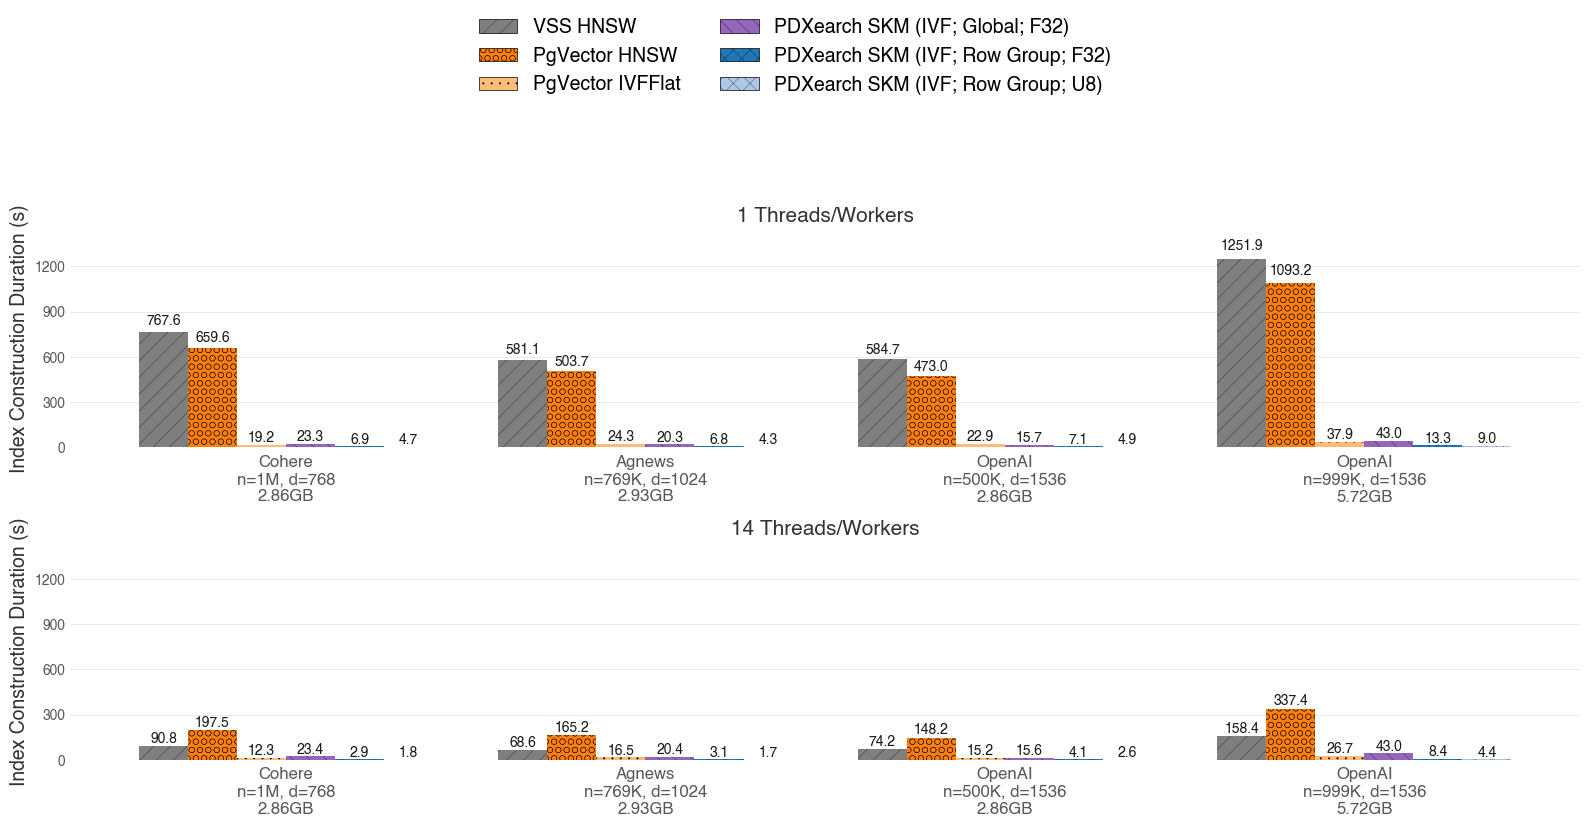

In [6]:
# ---------------------------------------------------------------------------
# 3. Plot: one subplot per dataset, bars grouped by (index, threads, global_version)
# ---------------------------------------------------------------------------
from collections import defaultdict
import re
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# Styling
mpl.rcParams['hatch.linewidth'] = 0.2
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

# Font settings (increased sizes)
label_fontsize = 14
tick_fontsize = 12
x_tick_fontsize = 12
bar_label_fontsize = 10
font_color = "#333333"
tick_fonts_color = '#585858'
bar_text_color = '#191919'

def parse_dataset_size(dataset_name: str) -> str:
    """Extract embeddings and dimensions from dataset name and compute size in GB."""
    # Parse patterns like "Cohere (1M × 768" or "OpenAI (500K × 1536"
    # or "Agnews (769K × 1024"
    match = re.match(r".*?\((\d+(?:\.\d+)?)\s*([KM]?)\s*×\s*(\d+)", dataset_name)
    if not match:
        return ""

    num_str, unit, dim_str = match.groups()
    num = float(num_str)
    dim = int(dim_str)

    # Convert to actual number of embeddings
    if unit == "K":
        num_embeddings = int(num * 1000)
    elif unit == "M":
        num_embeddings = int(num * 1_000_000)
    else:
        num_embeddings = int(num)

    # Size in bytes: num_embeddings * dimensions * 4 bytes per float32
    size_bytes = num_embeddings * dim * 4
    size_gb = size_bytes / (1024 ** 3)

    return f" ({size_gb:.2f} GB)"

def format_dataset_label(dataset_name: str) -> str:
    """Format dataset name with details: name, n, d, and size in GB."""
    # Parse the dataset name like "Cohere (1M × 768"
    match = re.match(r"(.+?)\s*\((\d+(?:\.\d+)?)\s*([KM]?)\s*×\s*(\d+)", dataset_name)
    if not match:
        return dataset_name.split("(")[0].strip()

    name, num_str, unit, dim_str = match.groups()
    name = name.strip()
    dim = int(dim_str)

    # Format n (number of embeddings)
    n_label = f"{num_str}{unit}" if unit else f"{num_str}"

    # Get size in GB
    size_str = parse_dataset_size(dataset_name)
    # Extract just the number from "(X.XX GB)"
    size_match = re.search(r"\(([\d.]+)\s*GB\)", size_str)
    size_gb = size_match.group(1) if size_match else "0.00"

    return f"{name}\nn={n_label}, d={dim}\n{size_gb}GB"

# Define the desired index ordering within each thread group:
# VSS → PgVector HNSW → PgVector IVFFlat → PDXearch (old) → PDXearch SKM F32 → PDXearch SKM U8
INDEX_ORDER = [
    "VSS HNSW",
    "PgVector HNSW",
    "PgVector IVFFlat",
    "PDXearch SKM (IVF; Global; F32)",
    # "PDXearch SKM (IVF; Global; U8)",
    "PDXearch SKM (IVF; Row Group; F32)",
    "PDXearch SKM (IVF; Row Group; U8)",
]

# Group records: dataset → thread_count → index_type → list of durations
grouped: dict[str, dict[int, dict[str, list[float]]]] = {
    ds: {1: defaultdict(list), 14: defaultdict(list)} for ds in datasets
}

for r in records:
    threads = r["threads"]
    if threads is not None:
        grouped[r["dataset"]][threads][r["index"]].append(r["optimize_duration"])

# Colors and hatches for index types (using built-in colorblind-friendly palette)
# Use tab10 colormap for colorblind-friendly colors
try:
    cmap = plt.colormaps['tab20']
except (AttributeError, KeyError):
    cmap = plt.cm.get_cmap('tab20')
index_colors = {
    "VSS HNSW": cmap(14),
    "PDXearch SKM (IVF; Global; F32)": cmap(8),
    # "PDXearch SKM (IVF; Global; U8)": cmap(15),
    "PDXearch SKM (IVF; Row Group; F32)": cmap(0),
    "PDXearch SKM (IVF; Row Group; U8)": cmap(1),
    "PgVector HNSW": cmap(2),
    "PgVector IVFFlat": cmap(3),
}

index_hatches = {
    "VSS HNSW": "//",
    "PDXearch SKM (IVF; Global; F32)": "\\\\",
    # "PDXearch SKM (IVF; Global; U8)": "\\\\",
    "PDXearch SKM (IVF; Row Group; F32)": "/\\/\\",
    "PDXearch SKM (IVF; Row Group; U8)": "xx",
    "PgVector HNSW": "OO",
    "PgVector IVFFlat": "..",
}

# Get all unique index types across all datasets and thread counts
all_index_types = set()
for dataset in datasets:
    for threads in [1, 14]:
        all_index_types.update(grouped[dataset][threads].keys())
all_index_types = [idx for idx in INDEX_ORDER if idx in all_index_types]
n_index_types = len(all_index_types)

# Create 2 subplots: one for 1T, one for 14T (stacked vertically)
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharey=False)
axes = axes.flatten()  # Flatten to make indexing easier

bar_width = 0.45  # Width of each bar
group_width = n_index_types * bar_width + 0.2  # Total width of a dataset group
group_spacing = 0.4  # Space between dataset groups

# First, collect all durations from graph 1 (Threads = 1) to determine shared y-axis limits
graph1_durations = []
for dataset in datasets:
    thread_data = grouped[dataset][1]
    for index_type in all_index_types:
        durations = thread_data.get(index_type, [])
        graph1_durations.extend(durations)

# Calculate shared y-axis limit from graph 1
if graph1_durations:
    shared_max_y = max(graph1_durations) * 1.15
else:
    shared_max_y = 100

for ax_idx, target_threads in enumerate([1, 14]):
    ax = axes[ax_idx]
    x_base = 0
    x_labels = []
    all_durations_for_ax = []

    for dataset in datasets:
        thread_data = grouped[dataset][target_threads]

        # Skip if no data for this thread count
        if not any(thread_data.values()):
            continue

        group_start = x_base
        for idx_idx, index_type in enumerate(all_index_types):
            x = group_start + idx_idx * bar_width

            durations = thread_data.get(index_type, [])
            if durations:
                mean_dur = np.mean(durations)
                all_durations_for_ax.extend(durations)
                color = index_colors.get(index_type, "#808080")
                hatch = index_hatches.get(index_type, "")
                ax.bar(x, mean_dur, bar_width, color=color, hatch=hatch,
                       label=index_type if dataset == datasets[0] else "")

                # Add value label on top of bar with offset
                offset = max(0.05, mean_dur * 0.03)
                ax.text(x, mean_dur + offset, f"{mean_dur:.1f}",
                       ha="center", va="bottom", fontsize=bar_label_fontsize, color=bar_text_color)

        # Use detailed dataset label for x-axis
        dataset_label = format_dataset_label(dataset)
        x_labels.append(dataset_label)
        x_base += group_width + group_spacing

    # Set title
    ax.set_title(f"{target_threads} Threads/Workers", fontsize=label_fontsize + 1, color=font_color)

    # Y label for all plots
    ax.set_ylabel("Index Construction Duration (s)", fontsize=label_fontsize, color=font_color)

    # Set x-ticks at the center of each dataset group
    group_centers = []
    x_base = 0
    for dataset in datasets:
        if any(grouped[dataset][target_threads].values()):
            center = x_base + (n_index_types - 1) * bar_width / 2
            group_centers.append(center)
            x_base += group_width + group_spacing

    ax.set_xticks(group_centers)
    ax.set_xticklabels(x_labels, fontsize=x_tick_fontsize, color=tick_fonts_color)

    # Grids (horizontal only)
    ax.yaxis.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
    ax.set_axisbelow(True)

    # Spine adjustments (remove top and right)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Y-axis limits and locator (use same limits as graph 1)
    ax.set_ylim(0, shared_max_y)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.tick_params(axis='y', colors=tick_fonts_color)
    ax.tick_params(axis='both', length=0)
    ax.tick_params(axis='x', pad=5)  # Increase spacing between x-axis labels and axis

# Shared legend - create handles for all index types
import math
from matplotlib.patches import Patch
legend_handles = []
legend_labels = []
for index_type in all_index_types:
    color = index_colors.get(index_type, "#808080")
    hatch = index_hatches.get(index_type, "")
    legend_handles.append(Patch(facecolor=color, hatch=hatch, edgecolor='black', linewidth=0.5))
    legend_labels.append(index_type)

fig.legend(legend_handles, legend_labels, loc="upper center", ncols=2,
          frameon=False, fontsize=label_fontsize, bbox_to_anchor=(0.5, 1.04))

fig.tight_layout(rect=[0, 0, 1, 0.80])
# plt.show()
plt.savefig("index_creation.png", dpi=300, bbox_inches='tight')
